In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from scipy import stats
from pathlib import Path
from collections import defaultdict
from matplotlib.patches import Rectangle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

from deep_learning.dataset_stack import RadarGaugeDataset

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
FIGSIZE_WIDE = (15, 5)
FIGSIZE_SQUARE = (8, 8)
FIGSIZE_TALL = (10, 12)

print("="*70)
print("MODEL EVALUATION FOR PRECIPITATION PREDICTION")
print("="*70)

# ============================================================================
# CONFIGURATION
# ============================================================================


CONFIG = {
    'train_data_path': './radar_gauge_dataset_9x9.pkl',
    'test_data_path': './radar_gauge_test_daily_9x9.pkl',
    'dem_path': './preserve_dem_10m_utm.tif',
    'stack_checkpoint': '../checkpoints/stack_99_bias3_weights_70_mae_biasflag_augment.pth',
    'output_dir': './evaluation_figures',
    'patch_size_m': 4620,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directory
Path(CONFIG['output_dir']).mkdir(exist_ok=True)

MODEL EVALUATION FOR PRECIPITATION PREDICTION
Using device: cuda


In [2]:
# ============================================================================
# 1. LOAD DATA
# ============================================================================

print("\n" + "="*70)
print("LOADING DATASETS")
print("="*70)

# Load training data
with open(CONFIG['train_data_path'], 'rb') as f:
    train_data = pickle.load(f)

# Load test data
with open(CONFIG['test_data_path'], 'rb') as f:
    test_data = pickle.load(f)

print(f"✓ Training samples: {len(train_data['train'])}")
print(f"✓ Validation samples: {len(train_data['val'])}")
print(f"✓ Test samples: {len(test_data['test'])}")


LOADING DATASETS
✓ Training samples: 16264
✓ Validation samples: 5999
✓ Test samples: 4743


In [3]:
# ============================================================================
# 2. DATASET STATISTICS
# ============================================================================

print("\n" + "="*70)
print("DATASET STATISTICS")
print("="*70)

def compute_dataset_stats(samples, is_daily=False):
    """Compute comprehensive statistics for a dataset"""
    
    # Extract precipitation values
    if is_daily:
        precip_key = 'daily_precip_mm'
        scale = 'daily'
    else:
        precip_key = 'hourly_precip_mm'
        scale = 'hourly'
    
    precip_values = [s[precip_key] for s in samples]
    
    # Get unique stations
    station_ids = set(s['station_id'] for s in samples)
    
    # Get unique dates (handle both 'date' key and 'hour_start' datetime)
    def get_date(s):
        if 'date' in s:
            return s['date']
        elif 'hour_start' in s:
            return s['hour_start'].date() if hasattr(s['hour_start'], 'date') else s['hour_start']
        return None
    dates = set(get_date(s) for s in samples if get_date(s) is not None)
    
    # Define bins
    if is_daily:
        bins = [0, 5, 20, 50, 100, np.inf]
        labels = ['0-5', '5-20', '20-50', '50-100', '100+']
    else:
        bins = [0, 1, 5, 10, 20, np.inf]
        labels = ['0-1', '1-5', '5-10', '10-20', '20+']
    
    # Bin the data
    precip_binned = pd.cut(precip_values, bins=bins, labels=labels)
    bin_counts = precip_binned.value_counts().sort_index()
    
    stats = {
        'n_samples': len(samples),
        'n_stations': len(station_ids),
        'n_days': len(dates),
        'precip_mean': np.mean(precip_values),
        'precip_median': np.median(precip_values),
        'precip_std': np.std(precip_values),
        'precip_min': np.min(precip_values),
        'precip_max': np.max(precip_values),
        'bin_counts': bin_counts,
        'bin_labels': labels,
        'scale': scale,
        'precip_values': precip_values,
        'station_ids': list(station_ids),
    }
    
    return stats

# Compute stats
train_stats = compute_dataset_stats(train_data['train'], is_daily=False)
val_stats = compute_dataset_stats(train_data['val'], is_daily=False)
test_stats = compute_dataset_stats(test_data['test'], is_daily=True)

# Print summary
def print_stats(stats, name):
    print(f"\n{name}:")
    print(f"  Samples: {stats['n_samples']}")
    print(f"  Stations: {stats['n_stations']}")
    print(f"  Days: {stats['n_days']}")
    print(f"  Precipitation ({stats['scale']}):")
    print(f"    Mean:   {stats['precip_mean']:.2f} mm")
    print(f"    Median: {stats['precip_median']:.2f} mm")
    print(f"    Std:    {stats['precip_std']:.2f} mm")
    print(f"    Range:  {stats['precip_min']:.2f} - {stats['precip_max']:.2f} mm")
    print(f"  Distribution:")
    for label, count in stats['bin_counts'].items():
        pct = 100 * count / stats['n_samples']
        print(f"    {label:10s}: {count:5d} ({pct:5.1f}%)")

print_stats(train_stats, "TRAINING")
print_stats(val_stats, "VALIDATION")
print_stats(test_stats, "TEST")


DATASET STATISTICS

TRAINING:
  Samples: 16264
  Stations: 15
  Days: 57
  Precipitation (hourly):
    Mean:   0.79 mm
    Median: 0.00 mm
    Std:    3.42 mm
    Range:  0.00 - 90.17 mm
  Distribution:
    0-1       :  3880 ( 23.9%)
    1-5       :  1886 ( 11.6%)
    5-10      :   386 (  2.4%)
    10-20     :   137 (  0.8%)
    20+       :    79 (  0.5%)

VALIDATION:
  Samples: 5999
  Stations: 15
  Days: 18
  Precipitation (hourly):
    Mean:   0.64 mm
    Median: 0.00 mm
    Std:    3.04 mm
    Range:  0.00 - 74.17 mm
  Distribution:
    0-1       :  1301 ( 21.7%)
    1-5       :   665 ( 11.1%)
    5-10      :    99 (  1.7%)
    10-20     :    27 (  0.5%)
    20+       :    22 (  0.4%)

TEST:
  Samples: 4743
  Stations: 14
  Days: 21
  Precipitation (daily):
    Mean:   19.11 mm
    Median: 11.00 mm
    Std:    20.00 mm
    Range:  1.00 - 88.68 mm
  Distribution:
    0-5       :   587 ( 12.4%)
    5-20      :  2730 ( 57.6%)
    20-50     :   957 ( 20.2%)
    50-100    :   469 (  9.

In [4]:
# ============================================================================
# 3. DATASET VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("GENERATING DATASET FIGURES")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# Row 1: Training & Validation (hourly)
# Distribution bars
for idx, (ds_stats, name) in enumerate([(train_stats, 'Training'), (val_stats, 'Validation')]):
    ax = axes[0, idx]
    ds_stats['bin_counts'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{name} - Precipitation Distribution')
    ax.set_xlabel('Rainfall (mm/hr)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Add percentages on bars
    for i, (label, count) in enumerate(ds_stats['bin_counts'].items()):
        pct = 100 * count / ds_stats['n_samples']
        ax.text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

# Combined train/val histogram
ax = axes[0, 2]
ax.hist([train_stats['precip_values'], val_stats['precip_values']], 
        bins=50, label=['Training', 'Validation'], alpha=0.6)
ax.set_xlabel('Rainfall (mm/hr)')
ax.set_ylabel('Frequency')
ax.set_title('Train vs Val Distribution')
ax.legend()
ax.set_xlim(0, 20)  # Focus on reasonable range

# Row 2: Test (daily)
ax = axes[1, 0]
test_stats['bin_counts'].plot(kind='bar', ax=ax, color='coral', alpha=0.7)
ax.set_title('Test - Precipitation Distribution (Daily)')
ax.set_xlabel('Rainfall (mm/day)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for i, (label, count) in enumerate(test_stats['bin_counts'].items()):
    pct = 100 * count / test_stats['n_samples']
    ax.text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

# Test histogram
ax = axes[1, 1]
ax.hist(test_stats['precip_values'], bins=30, color='coral', alpha=0.7)
ax.set_xlabel('Rainfall (mm/day)')
ax.set_ylabel('Frequency')
ax.set_title('Test Distribution')
ax.axvline(test_stats['precip_median'], color='red', linestyle='--', label=f"Median: {test_stats['precip_median']:.1f}mm")
ax.legend()

# Station counts
ax = axes[1, 2]
data_summary = pd.DataFrame({
    'Dataset': ['Train', 'Val', 'Test'],
    'Stations': [train_stats['n_stations'], val_stats['n_stations'], test_stats['n_stations']],
    'Samples': [train_stats['n_samples'], val_stats['n_samples'], test_stats['n_samples']]
})

x = np.arange(len(data_summary))
width = 0.35
ax.bar(x - width/2, data_summary['Stations'], width, label='Stations', alpha=0.7)
ax.bar(x + width/2, data_summary['Samples']/100, width, label='Samples (×100)', alpha=0.7)
ax.set_xlabel('Dataset')
ax.set_ylabel('Count')
ax.set_title('Dataset Summary')
ax.set_xticks(x)
ax.set_xticklabels(data_summary['Dataset'])
ax.legend()

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/01_dataset_overview.png", dpi=300, bbox_inches='tight')
print("✓ Saved: 01_dataset_overview.png")
plt.close()



GENERATING DATASET FIGURES
✓ Saved: 01_dataset_overview.png


In [5]:
# ============================================================================
# 4. LOAD STACK MODEL & GENERATE PREDICTIONS
# ============================================================================

print("\n" + "="*70)
print("LOADING STACK MODEL AND GENERATING PREDICTIONS")
print("="*70)

class RadarEncoder(nn.Module):
    """
    CNN encoder for radar reflectivity data.
    Adapted from paper architecture for small 5×5 spatial input.
    
    Architecture:
    - Max over altitude dimension (Z) → (batch, 6, 5, 5)
    - Conv-BN-Pool-Dropout blocks (2 blocks instead of 4 due to small spatial size)
    - Flatten and FC layers
    - Output: latent embedding for fusion with DEM features
    """
    
    def __init__(self, in_channels=12, latent_dim=256, dropout_rate=0.25):
        super(RadarEncoder, self).__init__()
        
        # First conv block: 6 → 32 channels
        # Input: (24, 5, 5), Output: (32, 5, 5)
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout1 = nn.Dropout2d(p=dropout_rate)
        
        # Second conv block with pooling: 32 → 64 channels
        # After conv: (64, 5, 5), After pool: (64, 2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)  # 5×5 → 2×2
        self.dropout2 = nn.Dropout2d(p=dropout_rate)
        
        # Third conv block: 64 → 128 channels
        # Output: (128, 2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout3 = nn.Dropout2d(p=dropout_rate)
        
        # Flatten: 128 * 2 * 2 = 512
        self.fc1 = nn.Linear(128 * 2 * 2, 256)
        self.dropout_fc1 = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(256, latent_dim)
        
        print(f"RadarEncoder initialized: {in_channels} channels → {latent_dim} latent dims")
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: (batch, 6, Z, 5, 5) radar reflectivity
            
        Returns:
            embeddings: (batch, latent_dim) feature vector
        """        

        # Conv block 1
        x = F.relu(self.bn1(self.conv1(x)))  # (batch, 32, 5, 5)
        x = self.dropout1(x)
        
        # Conv block 2 with pooling
        x = F.relu(self.bn2(self.conv2(x)))  # (batch, 64, 5, 5)
        x = self.pool2(x)                     # (batch, 64, 2, 2)
        x = self.dropout2(x)
        
        # Conv block 3
        x = F.relu(self.bn3(self.conv3(x)))  # (batch, 128, 2, 2)
        x = self.dropout3(x)
        
        # Flatten and FC layers
        x = torch.flatten(x, 1)              # (batch, 512)
        x = F.relu(self.fc1(x))              # (batch, 256)
        embeddings = self.fc2(x)             # (batch, latent_dim)
        
        return embeddings

class PrecipitationDecoder(nn.Module):
    """
    Decoder to produce 5×5 precipitation map from fused features.
    Uses LayerNorm instead of BatchNorm (works with any batch size).
    """
    
    def __init__(self, input_dim=512, hidden_dim=256, output_size=5):
        super(PrecipitationDecoder, self).__init__()
        
        self.output_size = output_size
        
        # MLP to decode fused features with LayerNorm
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 512 → 256
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.dropout1 = nn.Dropout(0.05)
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)  # 256 → 128
        self.ln2 = nn.LayerNorm(hidden_dim // 2)
        self.dropout2 = nn.Dropout(0.05)
        
        # Output layer: 25 values for 5×5 grid
        self.fc_out = nn.Linear(hidden_dim // 2, output_size * output_size)  # 128 → 25
        
        print(f"PrecipitationDecoder initialized: {input_dim} → {hidden_dim} → {hidden_dim // 2} → {output_size}×{output_size}")
    
    def forward(self, x):
        """Forward pass"""
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout2(x)
        
        # Output precipitation values - NO final ReLU!
        # MSE loss will naturally encourage positive predictions
        # Removing ReLU prevents dead neurons (58.5% were stuck at 0!)
        x = self.fc_out(x)
        
        # Reshape to 5×5 grid
        x = x.view(-1, self.output_size, self.output_size)
        
        return x

class PrecipitationDEMModel(nn.Module):
    """
    Complete model for precipitation prediction.
    
    Combines radar and DEM to predict 5×5 precipitation maps.
    """
    
    def __init__(self, latent_dim=256, n_radar_scans=12, add_bias=False):
        super(PrecipitationDEMModel, self).__init__()
        
        # Encoders
        radar_channels = n_radar_scans * 3 + 1 # a mask channel for each radar scan + dem channel
        self.radar_encoder = RadarEncoder(
            in_channels=radar_channels, 
            latent_dim=latent_dim
        )
        
        self.bias_embedding = nn.Embedding(
            num_embeddings=3,    # -1, 0, +1
            embedding_dim=32     # Small dimension
        )
        
        self.add_bias = add_bias
        # Decoder (takes encoder output + optional bias)
        if add_bias:
            decoder_input_dim = 256 + 32
        else:
            decoder_input_dim = 256
        self.decoder = PrecipitationDecoder(
            input_dim=decoder_input_dim,
            hidden_dim=512
        )
    
    def forward(self, radar, bias_flag=None):
        """
        Forward pass
        
        Args:
            radar: (batch, 25, Z, 5, 5) radar reflectivity
            
        Returns:
            precip_map: (batch, 5, 5) precipitation map in mm/hr
        """
        # Encode radar
        radar_emb = self.radar_encoder(radar)  # (batch, latent_dim)

        if bias_flag is not None:
            bias_idx = (bias_flag + 1).long()
            bias_emb = self.bias_embedding(bias_idx)
            
            combined = torch.cat([radar_emb, bias_emb], dim=1)  # (batch, 288)
            pred_map = self.decoder(combined)  # (batch, 5, 5)
        else:
            pred_map = self.decoder(radar_emb)
            
        return pred_map

# ----- Load Model -----
print(f"Loading Stack model from: {CONFIG['stack_checkpoint']}")
checkpoint = torch.load(CONFIG['stack_checkpoint'])

model = PrecipitationDEMModel(latent_dim=256, n_radar_scans=12, add_bias=True)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f"✓ Stack model loaded (epoch {checkpoint.get('epoch', '?')})")

# ----- Filter Functions (must match training) -----
def filter_biased_extremes(dataset):
    OVERESTIMATING_STATIONS = [
    'Dangermond_Bunker Hill', 'Dangermond_Cistern', 'Dangermond_Cojo HQ', 'Dangermond_Jalachichi','Dangermond_Repeator'  
    ]
    UNDERESTIMATING_STATIONS = [
        'Dangermond_Cojo Gate', 'Dangermond_Sutter'
    ]

    original_count = len(dataset.samples)
    filtered = []
    removed = []

    for sample in dataset.samples:
        station_name = sample['station_name']
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)
        # Overestimating stations: Remove extreme high values
        # (sensor flooding - can't distinguish droplet sizes)
        if station_name in OVERESTIMATING_STATIONS:
            if target > 25.0:  # Very heavy rain
                removed.append(f"{target:.1f}mm precipitation (overestimate)")
                continue
             # Filter out
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
    
        # Underestimating stations: Remove cases where radar says heavy but gauge says light
        # (sensor saturated/clogged)
        if station_name in UNDERESTIMATING_STATIONS:
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
                 # Filter out
        filtered.append(sample)

    dataset.samples = filtered
    print(f"✓ Filtered {len(removed)} samples ({original_count} → {len(filtered)})")
    for r in removed[:10]:
        print(f"    - {r}")
    if len(removed) > 10:
        print(f"    ... and {len(removed)-10} more")
    
    return dataset

def filter_bad_samples(dataset):
    """Filter bad samples including ground clutter"""
    original_count = len(dataset.samples)
    filtered = []
    removed = []
    
    for sample in dataset.samples:
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)

        if target > 40.0:
            removed.append(f"{target:.1f}mm precipitation (sensor error)")
            continue
        
        # EXISTING: Remove radar-gauge mismatch (high rain, low radar)
        if target > 5.0 and max_dbz < 20.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (radar miss)")
            continue

        
        # If dBZ > 50 but rain < 2mm, it's likely clutter
        if max_dbz > 50.0 and target < 2.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (ground clutter)")
            continue
        
        # NEW: Remove extreme dBZ (likely always clutter)
        if max_dbz > 60.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (extreme dBZ)")
            continue
            
        filtered.append(sample)
    
    dataset.samples = filtered
    print(f"✓ Filtered {len(removed)} samples ({original_count} → {len(filtered)})")
    for r in removed[:10]:
        print(f"    - {r}")
    if len(removed) > 10:
        print(f"    ... and {len(removed)-10} more")
    
    return dataset

def filter_suspect_station_days(dataset):
    """
    Filter out samples from station-days where the station recorded ZERO
    but other stations had significant rain (likely sensor issue).
    
    Keep samples if:
    1. Station had SOME rain that day (sensor was working), OR
    2. All stations had low rain that day (genuinely dry)
    """
    # First pass: calculate daily totals per station
    daily_totals = {}
    for sample in dataset.samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        precip = sample['hourly_precip_mm']
        
        key = (station, date)
        if key not in daily_totals:
            daily_totals[key] = 0
        daily_totals[key] += precip
    
    # Calculate daily network average (excluding each station)
    date_totals = {}
    for (station, date), total in daily_totals.items():
        if date not in date_totals:
            date_totals[date] = []
        date_totals[date].append((station, total))
    
    # Identify suspect station-days
    suspect_station_days = set()
    for date, station_data in date_totals.items():
        for station, total in station_data:
            if total == 0:  # Station had zero all day
                # Calculate average of OTHER stations
                others = [t for s, t in station_data if s != station]
                others_with_rain = sum(1 for t in others if t > 2.0)
                if len(others) >= 5 and others_with_rain >= 9 and np.mean(others) > 15:  # Others had significant rain
                    suspect_station_days.add((station, date))
    
    print(f"Identified {len(suspect_station_days)} suspect station-days")
    
    
    # Filter samples
    original_count = len(dataset.samples)
    filtered = []
    removed_count = 0
    
    for sample in dataset.samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        
        if (station, date) in suspect_station_days:
            removed_count += 1
            continue
        
        filtered.append(sample)
    
    dataset.samples = filtered
    print(f"✓ Removed {removed_count} samples from suspect station-days ({original_count} → {len(filtered)})")
    
    # Show which station-days were removed
    station_day_counts = {}
    for station, date in suspect_station_days:
        short = station.replace('Dangermond_', '')
        if short not in station_day_counts:
            station_day_counts[short] = []
        station_day_counts[short].append(date)
    
    print("\nRemoved station-days:")
    for station, dates in sorted(station_day_counts.items()):
        print(f"  {station}: {len(dates)} days → {dates[:5]}{'...' if len(dates) > 5 else ''}")
    
    return dataset# ----- Custom Collate (must match training) -----

def custom_collate(batch):
    """
    Custom collate function to handle gauge_pixel tuples and DEM properly.
    Converts list of tuples to a single tensor when all are the same.
    """
    # Extract all fields
    radar = torch.stack([item['radar'] for item in batch])
    target = torch.stack([item['target'] for item in batch])
    station_ids = [item['station_id'] for item in batch]
    hours = [item['hour'] for item in batch]
    
    # Handle gauge_pixel: convert list of tuples to tensor
    gauge_pixels = [item['gauge_pixel'] for item in batch]
    
    # Check if all gauge pixels are the same
    if all(gp == gauge_pixels[0] for gp in gauge_pixels):
        # All the same -> convert to single tensor [y, x]
        gauge_pixel = torch.tensor(gauge_pixels[0], dtype=torch.long)
    else:
        # Different locations -> stack into (batch, 2) tensor
        gauge_pixel = torch.stack([torch.tensor(gp, dtype=torch.long) for gp in gauge_pixels])
    
    # ✅ ADD THIS: Handle bias_flag
    bias_flags = [item.get('bias_flag', torch.tensor(0, dtype=torch.long)) for item in batch]
    bias_flag = torch.stack(bias_flags)
    
    return {
        'radar': radar,           
        'target': target,
        'gauge_pixel': gauge_pixel,
        'station_id': station_ids,
        'hour': hours,
        'bias_flag': bias_flag  # ✅ ADD THIS LINE!
    }

# ----- Create Datasets -----
print("\nCreating datasets...")
val_dataset = RadarGaugeDataset(
    CONFIG['train_data_path'], 
    dem_path=CONFIG['dem_path'],
    split='val',
    augment=False,
    patch_size_m=CONFIG['patch_size_m']
)

# Apply same filters as training!
val_dataset = filter_biased_extremes(val_dataset)
val_dataset = filter_bad_samples(val_dataset)
val_dataset = filter_suspect_station_days(val_dataset)

# ----- Generate Validation Predictions -----
print("\nGenerating validation predictions...")
val_preds = []
val_truths = []
max_precip = 100.0  # Same as training

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate)

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validation"):
        radar = batch['radar'].to(device)
        target = batch['target'].to(device)
        bias_flag = batch.get('bias_flag', torch.zeros(radar.size(0))).to(device)
        gauge_pixel = batch['gauge_pixel']
        
        if model.add_bias:
            pred_map = model(radar, bias_flag)
        else:
            pred_map = model(radar)
        
        # Extract predictions at gauge pixels (same logic as training notebook)
        if isinstance(gauge_pixel, tuple):
            y, x = gauge_pixel
            pred_at_gauge = pred_map[:, y, x]
        elif isinstance(gauge_pixel, torch.Tensor) and gauge_pixel.dim() == 1:
            y, x = gauge_pixel[0].item(), gauge_pixel[1].item()
            pred_at_gauge = pred_map[:, y, x]
        else:
            pred_at_gauge = torch.zeros_like(target)
            for i in range(len(target)):
                y, x = int(gauge_pixel[i, 0].item()), int(gauge_pixel[i, 1].item())
                pred_at_gauge[i] = pred_map[i, y, x]
        
        # Filter valid samples (same as training)
        valid_mask = (target >= 0)  # In log-space, all valid targets are >= 0
        
        if valid_mask.sum() > 0:
            # Convert from log-space to original space
            pred_original = torch.expm1(pred_at_gauge[valid_mask])
            target_original = torch.expm1(target[valid_mask])
            
            # Filter outliers in ORIGINAL space (same as training)
            outlier_mask = target_original <= max_precip
            
            if outlier_mask.sum() > 0:
                val_preds.extend(pred_original[outlier_mask].cpu().numpy().tolist())
                val_truths.extend(target_original[outlier_mask].cpu().numpy().tolist())

val_preds = np.array(val_preds)
val_truths = np.array(val_truths)
print(f"✓ Validation: {len(val_preds)} predictions")

# ----- Generate Test Predictions (Daily) -----
print("\nGenerating test predictions (daily aggregation)...")

# Helper function to prepare test input
def prepare_test_input(sample):
    DBZ_MIN, DBZ_MAX = -32.0, 70.0
    radar_patch = sample['radar_patch'].copy()
    
    # Center crop from 9×9 to 5×5
    input_size = radar_patch.shape[-1]
    output_size = 5
    if input_size > output_size:
        offset = (input_size - output_size) // 2
        radar_patch = radar_patch[:, :, offset:offset+output_size, offset:offset+output_size]
    
    radar_patch = np.where(radar_patch == -9999.0, DBZ_MIN, radar_patch)
    radar_patch = np.where(np.isnan(radar_patch), DBZ_MIN, radar_patch)
    radar_norm = np.clip((radar_patch - DBZ_MIN) / (DBZ_MAX - DBZ_MIN), 0, 1)
    
    mask = np.ones_like(radar_norm)
    for i, ridx in enumerate(sample.get('radar_indices', [])):
        if ridx is None:
            mask[i] = 0.0
            radar_norm[i] = 0.0
    
    radar_t = torch.from_numpy(radar_norm).float()
    mask_t = torch.from_numpy(mask).float()
    
    radar_maxz = torch.max(radar_t, dim=1)[0]
    mask_maxz = torch.max(mask_t, dim=1)[0]
    
    t_pos = torch.zeros_like(radar_maxz)
    for i in range(12):
        t_pos[i] = i / 11.0
    
    dem = torch.zeros(1, 5, 5)  # Simplified - using zeros for test
    
    radar_input = torch.cat([radar_maxz, mask_maxz, t_pos, dem], dim=0)
    return radar_input.unsqueeze(0).to(device)

# Group test samples by day-station
daily_groups = defaultdict(lambda: {'preds': [], 'truth': None})

for sample in tqdm(test_data['test'], desc="Test samples"):
    radar_input = prepare_test_input(sample)
    bias = torch.tensor([1], dtype=torch.long, device=device)  # Neutral bias
    
    with torch.no_grad():
        pred = model(radar_input, bias)
        pred_log = pred[0, 2, 2].item()  # Center pixel
        pred_mm = max(0, np.expm1(pred_log))
    
    # Get date (handle both 'date' key and 'hour_start' datetime)
    if 'date' in sample:
        sample_date = sample['date']
    else:
        sample_date = sample['hour_start'].date() if hasattr(sample['hour_start'], 'date') else sample['hour_start']
    
    key = (sample_date, sample['station_id'])
    daily_groups[key]['preds'].append(pred_mm)
    daily_groups[key]['truth'] = sample['daily_precip_mm']

# Aggregate daily predictions
test_preds = []
test_truths = []
for key, data in daily_groups.items():
    test_preds.append(sum(data['preds']))
    test_truths.append(data['truth'])

test_preds = np.array(test_preds)
test_truths = np.array(test_truths)
print(f"✓ Test: {len(test_preds)} daily predictions")

# Store results
model_results = {
    'stack': {
        'val_preds': val_preds,
        'val_truth': val_truths,
        'test_preds': test_preds,
        'test_truth': test_truths,
    }
}

print("\n✓ Model loading and prediction complete!")


LOADING STACK MODEL AND GENERATING PREDICTIONS
Loading Stack model from: ../checkpoints/stack_99_bias3_weights_70_mae_biasflag_augment.pth
RadarEncoder initialized: 37 channels → 256 latent dims
PrecipitationDecoder initialized: 288 → 512 → 256 → 5×5
✓ Stack model loaded (epoch 20)

Creating datasets...
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527), resolution=10.0m
Loaded val dataset:
  Samples: 5999
  Radar resolution: 500m
  Patch size: 4620m
✓ Filtered 584 samples (5999 → 5415)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.2mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    - 0.1mm precipitation (underestimate)
    - 0.0mm precipitation (underestimate)
    ... and 574 more
✓ Filtered 62 samples (5415 → 

Validation: 100%|██████████| 650/650 [00:11<00:00, 58.90it/s]


✓ Validation: 5196 predictions

Generating test predictions (daily aggregation)...


Test samples: 100%|██████████| 4743/4743 [00:07<00:00, 634.27it/s]

✓ Test: 208 daily predictions

✓ Model loading and prediction complete!


In [10]:
# ============================================================================
# 5. PERFORMANCE METRICS FUNCTIONS
# ============================================================================

def compute_metrics(preds, truth):
    """Compute comprehensive performance metrics"""
    
    # Standard metrics
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth)**2))
    
    ss_res = np.sum((truth - preds)**2)
    ss_tot = np.sum((truth - truth.mean())**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Linear fit (correlation)
    slope, intercept, r_value, p_value, std_err = stats.linregress(preds, truth)
    r2_corr = r_value**2
    
    # Bias
    bias = np.mean(preds - truth)
    
    metrics = {
        'n_samples': len(preds),
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'r2_corr': r2_corr,
        'slope': slope,
        'intercept': intercept,
        'bias': bias,
        'preds': preds,
        'truth': truth,
    }

    print("\n=== DIAGNOSTIC INFO ===")
    print(f"Val predictions: {len(val_preds)} samples")
    print(f"  Min: {val_preds.min():.3f}, Max: {val_preds.max():.3f}, Mean: {val_preds.mean():.3f}")
    print(f"Val truth: {len(val_truths)} samples") 
    print(f"  Min: {val_truths.min():.3f}, Max: {val_truths.max():.3f}, Mean: {val_truths.mean():.3f}")

    # Compute both R² metrics
    from scipy.stats import pearsonr
    pearson_r, _ = pearsonr(val_truths, val_preds)
    standard_r2 = 1 - np.sum((val_truths - val_preds)**2) / np.sum((val_truths - val_truths.mean())**2)
    correlation_r2 = pearson_r ** 2

    print(f"\nR² Metrics:")
    print(f"  Standard R²:    {standard_r2:.3f}")
    print(f"  Correlation R²: {correlation_r2:.3f} ← Compare to training notebook")
    print(f"  Pearson r:      {pearson_r:.3f}")
    
    return metrics

def compute_binned_metrics(preds, truth, bins, labels):
    """Compute metrics binned by precipitation intensity"""
    
    truth_binned = pd.cut(truth, bins=bins, labels=labels)
    
    binned_results = []
    for label in labels:
        mask = (truth_binned == label)
        if mask.sum() > 0:
            bin_preds = preds[mask]
            bin_truth = truth[mask]
            
            binned_results.append({
                'bin': label,
                'n': mask.sum(),
                'mae': np.mean(np.abs(bin_preds - bin_truth)),
                'rmse': np.sqrt(np.mean((bin_preds - bin_truth)**2)),
                'bias': np.mean(bin_preds - bin_truth),
                'mean_truth': np.mean(bin_truth),
                'mean_pred': np.mean(bin_preds),
            })
    
    return pd.DataFrame(binned_results)

In [ ]:
# ============================================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_scatter_with_stats(preds, truth, title, save_path):
    """Create scatter plot with regression line and statistics"""
    
    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    
    # Scatter
    ax.scatter(preds, truth, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
    
    # Perfect prediction line
    max_val = max(preds.max(), truth.max())
    ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect (y=x)', linewidth=2)
    
    # Linear fit
    slope, intercept, r_value, _, _ = stats.linregress(preds, truth)
    fit_line = slope * preds + intercept
    ax.plot(preds, fit_line, 'r-', label=f'Fit: y={slope:.2f}x + {intercept:.1f}', linewidth=2)
    
    # Compute metrics
    metrics = compute_metrics(preds, truth)
    
    # Add text box with stats
    textstr = '\n'.join([
        f'N = {metrics["n_samples"]}',
        f'R² = {metrics["r2"]:.3f}',
        f'R² (corr) = {metrics["r2_corr"]:.3f}',
        f'MAE = {metrics["mae"]:.2f}',
        f'RMSE = {metrics["rmse"]:.2f}',
        f'Bias = {metrics["bias"]:.2f}',
    ])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    ax.set_xlabel('Predicted (mm)', fontsize=12)
    ax.set_ylabel('Observed (mm)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def plot_error_by_intensity(binned_df, title, save_path, metric='mae'):
    """Plot error metrics binned by precipitation intensity"""
    
    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
    
    x = np.arange(len(binned_df))
    
    if metric == 'rmse':
        label = 'RMsE (mm)'
        title = 'RMSE'
    else:
        label = 'MAE (mm)'
        title = 'Mean Absolute Error'
        
    # MAE
    axes[0].bar(x, binned_df['mae'], alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Rainfall Bin')
    axes[0].set_ylabel(label)
    axes[0].set_title(title)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(binned_df['bin'], rotation=45)
    
    # Bias
    axes[1].bar(x, binned_df['bias'], alpha=0.7, color='coral')
    axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Rainfall Bin')
    axes[1].set_ylabel('Bias (mm)')
    axes[1].set_title('Mean Bias (Pred - Obs)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(binned_df['bin'], rotation=45)
    
    # Sample count
    axes[2].bar(x, binned_df['n'], alpha=0.7, color='green')
    axes[2].set_xlabel('Rainfall Bin')
    axes[2].set_ylabel('Sample Count')
    axes[2].set_title('Samples per Bin')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(binned_df['bin'], rotation=45)
    axes[2].set_yscale('log')
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()



MODEL PERFORMANCE VISUALIZATION

📊 Generating validation scatter plot...

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575
✓ Saved: 02_stack_validation_scatter.png

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575


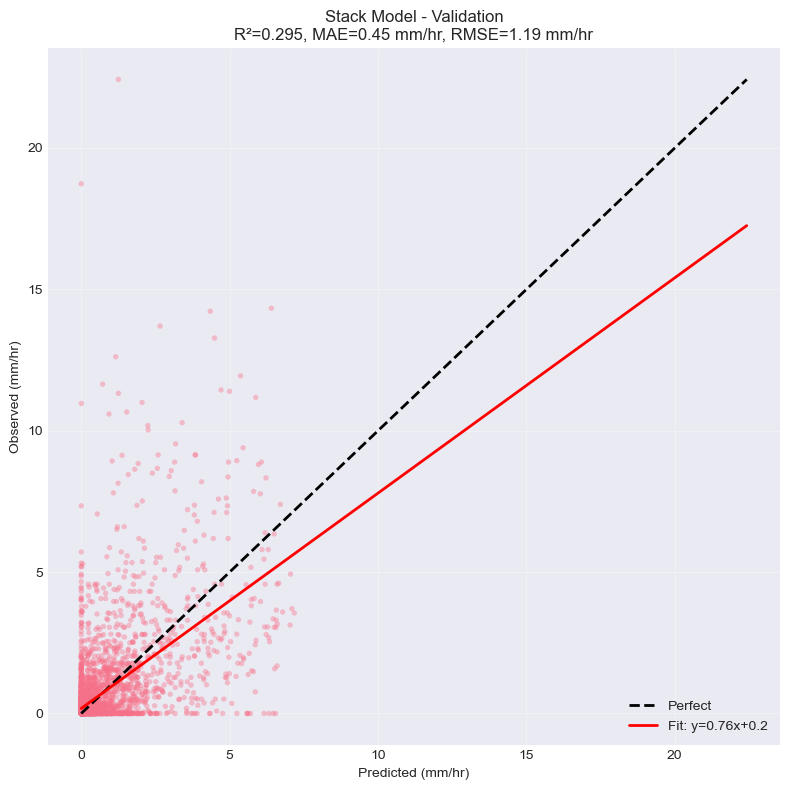


📊 Generating test scatter plot (daily)...

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575
✓ Saved: 03_stack_test_scatter.png

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575


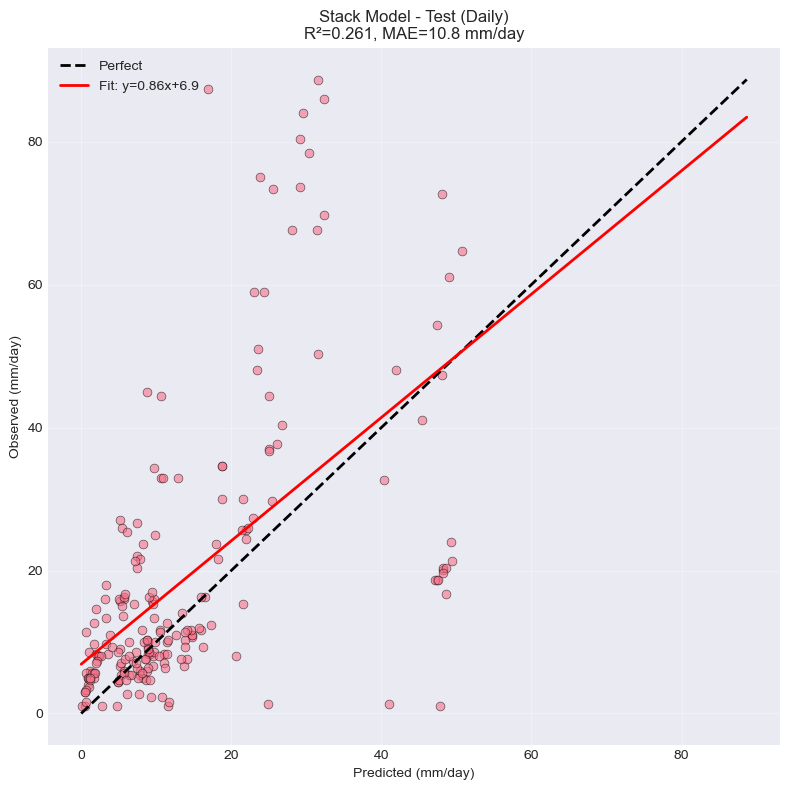


📊 Generating error by intensity plot...
✓ Saved: 04_stack_validation_error_bins.png


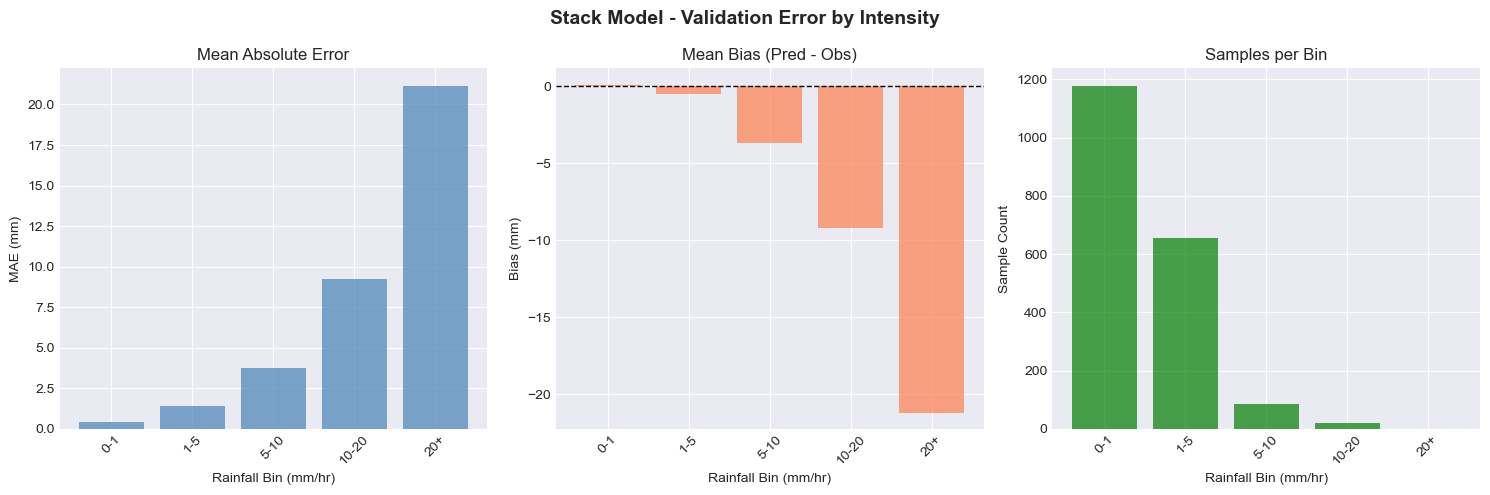


✓ All figures generated!


In [ ]:
# ============================================================================
# 7. GENERATE MODEL PERFORMANCE FIGURES
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE VISUALIZATION")
print("="*70)

# ===== VALIDATION SCATTER PLOT =====
print("\n📊 Generating validation scatter plot...")
plot_scatter_with_stats(
    model_results['stack']['val_preds'],
    model_results['stack']['val_truth'],
    'Stack Model - Validation Set (Hourly)',
    f"{CONFIG['output_dir']}/02_stack_validation_scatter.png"
)
print("✓ Saved: 02_stack_validation_scatter.png")

# Also display inline
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_results['terratorch']['val_preds'], model_results['stack']['val_truth'], 
           alpha=0.4, s=15, edgecolors='none')
max_val = max(model_results['stack']['val_preds'].max(), model_results['stack']['val_truth'].max())
ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect', linewidth=2)

# Fit line
slope, intercept, r_val, _, _ = stats.linregress(model_results['stack']['val_preds'], 
                                                   model_results['stack']['val_truth'])
ax.plot([0, max_val], [intercept, slope*max_val + intercept], 'r-', 
        label=f'Fit: y={slope:.2f}x+{intercept:.1f}', linewidth=2)

metrics = compute_metrics(model_results['stack']['val_preds'], model_results['stack']['val_truth'])
ax.set_xlabel('Predicted (mm/hr)')
ax.set_ylabel('Observed (mm/hr)')
ax.set_title(f"Stack Model - Validation\nR²={metrics['r2']:.3f}, MAE={metrics['mae']:.2f} mm/hr, RMSE={metrics['rmse']:.2f} mm/hr")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== TEST SCATTER PLOT (DAILY) =====
print("\n📊 Generating test scatter plot (daily)...")
plot_scatter_with_stats(
    model_results['stack']['test_preds'],
    model_results['stack']['test_truth'],
    'Stack Model - Test Set (Daily)',
    f"{CONFIG['output_dir']}/03_stack_test_scatter.png"
)
print("✓ Saved: 03_stack_test_scatter.png")

# Also display inline
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_results['stack']['test_preds'], model_results['stack']['test_truth'], 
           alpha=0.6, s=40, edgecolors='k', linewidth=0.5)
max_val = max(model_results['stack']['test_preds'].max(), model_results['stack']['test_truth'].max())
ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect', linewidth=2)

slope, intercept, r_val, _, _ = stats.linregress(model_results['stack']['test_preds'], 
                                                   model_results['stack']['test_truth'])
ax.plot([0, max_val], [intercept, slope*max_val + intercept], 'r-', 
        label=f'Fit: y={slope:.2f}x+{intercept:.1f}', linewidth=2)

metrics_test = compute_metrics(model_results['stack']['test_preds'], model_results['stack']['test_truth'])
ax.set_xlabel('Predicted (mm/day)')
ax.set_ylabel('Observed (mm/day)')
ax.set_title(f"Stack Model - Test (Daily)\nR²={metrics_test['r2']:.3f}, MAE={metrics_test['mae']:.1f} mm/day")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== ERROR BY PRECIPITATION INTENSITY =====
print("\n📊 Generating error by intensity plot...")
hourly_bins = [0, 1, 5, 10, 20, np.inf]
hourly_labels = ['0-1', '1-5', '5-10', '10-20', '20+']

stack_val_binned = compute_binned_metrics(
    model_results['stack']['val_preds'],
    model_results['stack']['val_truth'],
    hourly_bins,
    hourly_labels
)

plot_error_by_intensity(
    stack_val_binned,
    'Stack Model - Validation Error by Intensity',
    f"{CONFIG['output_dir']}/04_stack_validation_error_bins.png"
)
print("✓ Saved: 04_stack_validation_error_bins.png")

# Also display inline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(len(stack_val_binned))

axes[0].bar(x, stack_val_binned['mae'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Rainfall Bin (mm/hr)')
axes[0].set_ylabel('MAE (mm)')
axes[0].set_title('Mean Absolute Error')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stack_val_binned['bin'], rotation=45)

axes[1].bar(x, stack_val_binned['bias'], alpha=0.7, color='coral')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('Rainfall Bin (mm/hr)')
axes[1].set_ylabel('Bias (mm)')
axes[1].set_title('Mean Bias (Pred - Obs)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stack_val_binned['bin'], rotation=45)

axes[2].bar(x, stack_val_binned['n'], alpha=0.7, color='green')
axes[2].set_xlabel('Rainfall Bin (mm/hr)')
axes[2].set_ylabel('Sample Count')
axes[2].set_title('Samples per Bin')
axes[2].set_xticks(x)
axes[2].set_xticklabels(stack_val_binned['bin'], rotation=45)

fig.suptitle('Stack Model - Validation Error by Intensity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ All figures generated!")

In [9]:
# ============================================================================
# 8. SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print("\n📊 Dataset Summary:")
summary_df = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'Samples': [train_stats['n_samples'], val_stats['n_samples'], test_stats['n_samples']],
    'Stations': [train_stats['n_stations'], val_stats['n_stations'], test_stats['n_stations']],
    'Scale': ['Hourly', 'Hourly', 'Daily'],
    'Mean (mm)': [train_stats['precip_mean'], val_stats['precip_mean'], test_stats['precip_mean']],
    'Median (mm)': [train_stats['precip_median'], val_stats['precip_median'], test_stats['precip_median']],
})

print(summary_df.to_string(index=False))

print("\n📊 Model Performance Summary:")
val_metrics = compute_metrics(model_results['stack']['val_preds'], model_results['stack']['val_truth'])
test_metrics = compute_metrics(model_results['stack']['test_preds'], model_results['stack']['test_truth'])

perf_df = pd.DataFrame({
    'Metric': ['R²', 'Correlation R²', 'MAE', 'RMSE', 'Bias'],
    'Validation (hourly)': [
        f"{val_metrics['r2']:.3f}",
        f"{val_metrics['r2_corr']:.3f}",
        f"{val_metrics['mae']:.2f} mm/hr",
        f"{val_metrics['rmse']:.2f} mm/hr",
        f"{val_metrics['bias']:.2f} mm/hr",
    ],
    'Test (daily)': [
        f"{test_metrics['r2']:.3f}",
        f"{test_metrics['r2_corr']:.3f}",
        f"{test_metrics['mae']:.1f} mm/day",
        f"{test_metrics['rmse']:.1f} mm/day",
        f"{test_metrics['bias']:.1f} mm/day",
    ],
})

print(perf_df.to_string(index=False))

print(f"\n📁 Figures saved to: {CONFIG['output_dir']}")
print("  - 01_dataset_overview.png")
print("  - 02_stack_validation_scatter.png")
print("  - 03_stack_test_scatter.png")
print("  - 04_stack_validation_error_bins.png")

print("\n✓ Evaluation complete!")
print("="*70)


SUMMARY

📊 Dataset Summary:
   Dataset  Samples  Stations  Scale  Mean (mm)  Median (mm)
  Training    16264        15 Hourly   0.788775       0.0000
Validation     5999        15 Hourly   0.638680       0.0000
      Test     4743        14  Daily  19.105655      11.0022

📊 Model Performance Summary:

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575
        Metric Validation (hourly) Test (daily)
            R²               0.257        0.261
Correlation R²               0.299        0.332
       

In [33]:
# ============================================================================
# TERRATORCH MODEL EVALUATION
# ============================================================================

print("\n" + "="*70)
print("LOADING TERRATORCH MODEL AND GENERATING PREDICTIONS")
print("="*70)

import lightning as L
from terratorch.tasks import PixelwiseRegressionTask
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def filter_biased_extremes(samples):
    OVERESTIMATING_STATIONS = [
    'Dangermond_Bunker Hill', 'Dangermond_Cistern', 'Dangermond_Cojo HQ', 'Dangermond_Jalachichi','Dangermond_Repeator'  
    ]
    UNDERESTIMATING_STATIONS = [
        'Dangermond_Cojo Gate', 'Dangermond_Sutter'
    ]

    filtered = []
    removed = []

    for sample in samples:
        station_name = sample['station_name']
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)
        # Overestimating stations: Remove extreme high values
        # (sensor flooding - can't distinguish droplet sizes)
        if station_name in OVERESTIMATING_STATIONS:
            if target > 25.0:  # Very heavy rain
                removed.append(f"{target:.1f}mm precipitation (overestimate)")
                continue
             # Filter out
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
    
        # Underestimating stations: Remove cases where radar says heavy but gauge says light
        # (sensor saturated/clogged)
        if station_name in UNDERESTIMATING_STATIONS:
            if max_dbz > 30.0 and target < 0.3:  # Radar detects storm but gauge reads low
                removed.append(f"{target:.1f}mm precipitation (underestimate)")
                continue
                 # Filter out
        filtered.append(sample)

    print(f"✓ Filtered {len(removed)} samples")
    
    return filtered

def filter_bad_samples(samples):
    """Filter bad samples including ground clutter"""
    filtered = []
    removed = []
    
    for sample in samples:
        target = sample['hourly_precip_mm']
        radar = sample['radar_patch']
        max_dbz = np.nanmax(radar)

        if target > 40.0:
            removed.append(f"{target:.1f}mm precipitation (sensor error)")
            continue
        
        # EXISTING: Remove radar-gauge mismatch (high rain, low radar)
        if target > 5.0 and max_dbz < 20.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (radar miss)")
            continue

        
        # If dBZ > 50 but rain < 2mm, it's likely clutter
        if max_dbz > 50.0 and target < 2.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (ground clutter)")
            continue
        
        # NEW: Remove extreme dBZ (likely always clutter)
        if max_dbz > 60.0:
            removed.append(f"{target:.1f}mm @ {max_dbz:.1f}dBZ (extreme dBZ)")
            continue
            
        filtered.append(sample)
    
    print(f"✓ Filtered {len(removed)} samples")
    
    
    return filtered

def filter_suspect_station_days(samples):
    """
    Filter out samples from station-days where the station recorded ZERO
    but other stations had significant rain (likely sensor issue).
    
    Keep samples if:
    1. Station had SOME rain that day (sensor was working), OR
    2. All stations had low rain that day (genuinely dry)
    """
    # First pass: calculate daily totals per station
    daily_totals = {}
    for sample in samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        precip = sample['hourly_precip_mm']
        
        key = (station, date)
        if key not in daily_totals:
            daily_totals[key] = 0
        daily_totals[key] += precip
    
    # Calculate daily network average (excluding each station)
    date_totals = {}
    for (station, date), total in daily_totals.items():
        if date not in date_totals:
            date_totals[date] = []
        date_totals[date].append((station, total))
    
    # Identify suspect station-days
    suspect_station_days = set()
    for date, station_data in date_totals.items():
        for station, total in station_data:
            if total == 0:  # Station had zero all day
                # Calculate average of OTHER stations
                others = [t for s, t in station_data if s != station]
                others_with_rain = sum(1 for t in others if t > 2.0)
                if len(others) >= 5 and others_with_rain >= 9 and np.mean(others) > 15:  # Others had significant rain
                    suspect_station_days.add((station, date))
    
    print(f"Identified {len(suspect_station_days)} suspect station-days")

    # Filter samples
    filtered = []
    removed_count = 0
    
    for sample in samples:
        station = sample.get('station_name', 'Unknown')
        hour_str = str(sample.get('hour_start', ''))
        date = hour_str[:10]
        
        if (station, date) in suspect_station_days:
            removed_count += 1
            continue
        
        filtered.append(sample)
    
    print(f"✓ Removed {removed_count} samples from suspect station-days")
    
    # Show which station-days were removed
    station_day_counts = {}
    for station, date in suspect_station_days:
        short = station.replace('Dangermond_', '')
        if short not in station_day_counts:
            station_day_counts[short] = []
        station_day_counts[short].append(date)
    
    return filtered


# ----- TerraTorch Dataset Class -----
class RadarDEMDataset(Dataset):
    
    DBZ_MIN = -32.0
    DBZ_MAX = 70.0
    
    def __init__(self, samples, dem_path='./preserve_dem_10m_utm.tif', patch_size_m=4620, augment=False, aug_prob=0.5):
        self.samples = samples
        self.patch_size_m = patch_size_m
        self.augment = augment
        self.aug_prob = aug_prob
        
        # Load DEM once into memory (if provided)
        self.dem = None
        if dem_path:
            import rioxarray as rxr
            print(f"  Loading DEM from {dem_path}...")
            dem_data = rxr.open_rasterio(dem_path)
            self.dem = dem_data.values  # (1, H, W) numpy array
            self.dem_x = dem_data.x.values
            self.dem_y = dem_data.y.values
            self.dem_resolution = abs(dem_data.rio.resolution()[0])
            print(f"  ✓ DEM loaded: shape={self.dem.shape}")
    
    def __len__(self):
        return len(self.samples)
    
    def _extract_dem_patch(self, station_lat, station_lon):
        """Extract DEM patch centered on station (on-the-fly)"""
        from pyproj import Transformer
        
        transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32610', always_xy=True)
        station_x, station_y = transformer.transform(station_lon, station_lat)
        
        patch_pixels = int(self.patch_size_m / self.dem_resolution)
        half_pixels = patch_pixels // 2
        
        x_idx = np.abs(self.dem_x - station_x).argmin()
        y_idx = np.abs(self.dem_y - station_y).argmin()
        
        x_start = max(0, x_idx - half_pixels)
        x_end = x_start + patch_pixels
        y_start = max(0, y_idx - half_pixels)
        y_end = y_start + patch_pixels
        
        if x_end > len(self.dem_x):
            x_end = len(self.dem_x)
            x_start = max(0, x_end - patch_pixels)
        if y_end > len(self.dem_y):
            y_end = len(self.dem_y)
            y_start = max(0, y_end - patch_pixels)
        
        patch = self.dem[:, y_start:y_end, x_start:x_end].copy()
        
        if patch.shape[1] != patch_pixels or patch.shape[2] != patch_pixels:
            padded = np.zeros((1, patch_pixels, patch_pixels), dtype=patch.dtype)
            h, w = patch.shape[1], patch.shape[2]
            padded[:, :h, :w] = patch
            patch = padded
        
        return patch
    
    def _process_radar(self, radar_patch, radar_indices):
        """
        Process radar with temporal awareness channels.
        Returns: (48, 256, 256) - 12 radar + 12 mask + 12 tpos + 12 deltas
        """
        radar_arr = radar_patch.copy()

        radar_arr[radar_arr == -9999.0] = self.DBZ_MIN
        radar_arr = np.where(np.isnan(radar_arr), self.DBZ_MIN, radar_arr)
        
        radar_norm = (radar_arr - self.DBZ_MIN) / (self.DBZ_MAX - self.DBZ_MIN)
        radar_norm = np.clip(radar_norm, 0, 1)
        
        mask = np.ones_like(radar_norm)

        for i, ridx in enumerate(radar_indices):
            if ridx is None:
                mask[i, :, :, :] = 0.0
                radar_norm[i, :, :, :] = 0.0

        # Convert to tensors
        radar_t = torch.from_numpy(radar_norm).float()  # (12, 40, 5, 5)
        mask_t = torch.from_numpy(mask).float()          # (12, 40, 5, 5)
        
        # === TAKE MAX OVER Z DIMENSION FIRST ===
        radar_maxz, _ = torch.max(radar_t, dim=1)  # (12, 5, 5)
        mask_maxz, _ = torch.max(mask_t, dim=1)    # (12, 5, 5)

        # ---- Build temporal positional channels ----
        # Now shape is (12, 5, 5)
        t_pos = torch.zeros_like(radar_maxz)
        for i in range(12):
            t_pos[i] = i / 11.0   # normalized 0..1

        # Stack all channels: (48, 5, 5)
        radar_all = torch.cat([radar_maxz, mask_maxz, t_pos], dim=0)

        # Upscale to 256x256
        radar_up = F.interpolate(
            radar_all.unsqueeze(0),
            size=(256, 256),
            mode='nearest'
        ).squeeze(0)

        return radar_up  # (36, 256, 256)
    
    def _process_dem(self, dem_patch):
        """Process DEM: NaN → resize to 256×256"""
        dem_arr = dem_patch.copy()
        
        if dem_arr.ndim == 2:
            dem_arr = dem_arr[np.newaxis, :, :]
        
        dem_arr = np.where(np.isnan(dem_arr), 0.0, dem_arr)
        dem_t = torch.from_numpy(dem_arr).float()
        
        # Resize to 256×256 (handles any input size)
        if dem_t.shape[-1] != 256 or dem_t.shape[-2] != 256:
            dem_t = F.interpolate(
                dem_t.unsqueeze(0), 
                size=(256, 256), 
                mode='bilinear', 
                align_corners=False
            ).squeeze(0)
        
        return dem_t  # (1, 256, 256)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        radar_patch = s['radar_patch'].copy()  # (12, 40, 9, 9) for 9x9 patches
        
        # === Random crop from 9×9 to 5×5 ===
        input_size = radar_patch.shape[-1]  # 9 for 9x9, 5 for legacy
        output_size = 5
        
        if input_size > output_size:
            max_offset = input_size - output_size  # = 4
            
            if self.augment and np.random.rand() < self.aug_prob:
                # Random crop during training
                offset_y = np.random.randint(0, max_offset + 1)
                offset_x = np.random.randint(0, max_offset + 1)
            else:
                # Center crop during validation
                offset_y = max_offset // 2
                offset_x = max_offset // 2
            
            # Where gauge ends up in the cropped 5×5
            center_pos = input_size // 2  # = 4 for 9×9
            gauge_y = center_pos - offset_y
            gauge_x = center_pos - offset_x
            
            # Crop radar from 9×9 to 5×5
            radar_patch = radar_patch[:, :, offset_y:offset_y+output_size, offset_x:offset_x+output_size]
        else:
            offset_y, offset_x = 0, 0
            gauge_y, gauge_x = 2, 2  # Center of 5×5
        
        radar_t = self._process_radar(radar_patch, s.get("radar_indices"))
        
        # Extract DEM on-the-fly with same offset
        if self.dem is not None:
            dem_patch_full = self._extract_dem_patch(s['station_lat'], s['station_lon'])
            # Downsample to input_size, then crop with same offset
            if input_size > output_size:
                dem_t_full = torch.from_numpy(dem_patch_full).float()
                dem_t_sized = F.interpolate(dem_t_full.unsqueeze(0), size=(input_size, input_size), mode='bilinear', align_corners=False).squeeze(0)
                dem_patch = dem_t_sized[:, offset_y:offset_y+output_size, offset_x:offset_x+output_size].numpy()
            else:
                dem_patch = dem_patch_full
        elif 'dem_patch' in s and s['dem_patch'] is not None:
            dem_patch = s['dem_patch']
        else:
            dem_patch = np.zeros((1, 264, 264))
        
        dem_t = self._process_dem(dem_patch)

        image = {
            "DEM": dem_t,      # (1, 256, 256)
            "RADAR": radar_t   # (36, 256, 256)
        }

        target_value = np.log1p(s['hourly_precip_mm'])
    
        # Create 5x5 mask with target at gauge position
        mask = torch.full((5, 5), -9999.0, dtype=torch.float32)  # Ignore value
        mask[gauge_y, gauge_x] = target_value  # Target at actual gauge position!
        
        return {
            'image': image,    # ← TerraTorch expects this key!
            'mask': mask,
        }

class RadarDEMDataModule(L.LightningDataModule):
    def __init__(self, pickle_path: str, weight_sampler=None, batch_size=32, num_workers=0):
        super().__init__()
        self.pickle_path = pickle_path
        self.batch_size = batch_size
        self.num_workers = num_workers

        self.train_samples = None
        self.val_samples = None
        
        self.weight_sampler = weight_sampler
        self.train_sampler = None

    def prepare_data(self):
        # no heavy downloads
        pass

    def setup(self, stage=None):

        # load data from pickle
        data = pickle.load(open(self.pickle_path, "rb"))
        train_samples, val_samples = data["train"], data["val"]
        
        # filter samples that may have sensor error or radar issues
        train_samples = filter_biased_extremes(train_samples) 
        val_samples = filter_biased_extremes(val_samples)

        train_samples = filter_bad_samples(train_samples) 
        val_samples = filter_bad_samples(val_samples)

        train_samples = filter_suspect_station_days(train_samples) 
        val_samples = filter_suspect_station_days(val_samples)

        self.train_ds = RadarDEMDataset(train_samples, patch_size_m=4620, augment=True, aug_prob=0.5)
        self.val_ds = RadarDEMDataset(val_samples, patch_size_m=4620, augment=False)

        # add a weight sampler to training data if configured
        if self.weight_sampler is not None:
            self.train_sampler = self.weight_sampler(train_samples)
        

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True)
 
class SpatialPrecipitationDecoder(nn.Module):
    """
    Decodes spatial features to a 5×5 precipitation map.
    Compatible with TerraTorch's multi-scale feature lists.
    """
    includes_head = False

    def __init__(self, in_channels=192, target_size=5, output_bias=2.0):
        super().__init__()
        
        self.out_channels = 1
        
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        
        self.conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        
        self.conv_out = nn.Conv2d(32, 1, kernel_size=1)
        self.final_pool = nn.AdaptiveAvgPool2d((target_size, target_size))

        with torch.no_grad():
            self.conv_out.bias.data.fill_(output_bias)
        
    def forward(self, x):
        """
        Input: List of feature tensors OR single tensor
        Output: (batch, 5, 5) - precipitation map
        """
        # === HANDLE LIST INPUT FROM TERRATORCH ===
        if isinstance(x, list):
            # Take the last feature map (highest-level features)
            x = x[-1]
        
        # If features are (batch, patches, channels), reshape to spatial
        if x.dim() == 3:
            batch_size, num_patches, feat_dim = x.shape
            H = W = int(num_patches ** 0.5)  # e.g., 256 patches → 16×16
            x = x.transpose(1, 2).reshape(batch_size, feat_dim, H, W)
        
        # Now x should be (batch, channels, H, W)
        x = F.relu(self.bn1(self.conv1(x)))  # (B, 128, H, W)
        x = F.relu(self.bn2(self.conv2(x)))  # (B, 64, H, W)
        x = F.relu(self.bn3(self.conv3(x)))  # (B, 32, H, W)
        
        x = self.conv_out(x)  # (B, 1, H, W)
        x = self.final_pool(x)  # (B, 1, 5, 5)
        
        # DON'T squeeze - TerraTorch expects (B, C, H, W) output
        return x  # (B, 1, 5, 5)

best_model_path = r"C:\Users\danwillett\Code\geofms\checkpoints\terratorch_5x5_time_unfreeze_weights_bias_3\best-epoch=10-val_loss=0.0000.ckpt"
print(f"Loading model from: {best_model_path}")

# === LOAD THE MODEL ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = PixelwiseRegressionTask.load_from_checkpoint(
    best_model_path
)
best_model.eval()
best_model.to(device)

print("✓ Model loaded successfully!")

from torch.utils.data import WeightedRandomSampler

def create_heavy_rain_sampler(samples):
    """
    Heavily oversample the rare heavy rain events.
    With only 4.5% heavy rain, we need aggressive weights!
    """
    targets = np.array([s['hourly_precip_mm'] for s in samples])
    
    # Create weights based on precipitation intensity
    weights = np.ones(len(targets))
    
    # Zero/trace rain: undersample slightly
    weights[targets < 0.1] = 0.5
    
    # Light rain (0.1-2mm): normal weight
    weights[(targets >= 0.1) & (targets < 2)] = 1.0
    
    # Moderate rain (2-5mm): slight oversample
    weights[(targets >= 2) & (targets < 5)] = 2.0
    
    # Heavy rain (5-15mm): moderate oversample
    weights[(targets >= 5) & (targets < 15)] = 5.0
    
    # Very heavy rain (15-40mm): heavier oversample
    weights[(targets >= 15) & (targets <= 40)] = 10.0
    
    # Normalize
    weights = weights / weights.sum() * len(weights)
    
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )
    
    # Report effective distribution
    effective_pct = weights / weights.sum() * 100
    print(f"\n{'='*50}")
    print(f"WEIGHTED SAMPLER CREATED")
    print(f"{'='*50}")
    print(f"Category          | Original | Effective")
    print(f"------------------|----------|----------")
    print(f"Zero rain         | {(targets==0).mean()*100:5.1f}%   | {effective_pct[targets==0].sum():5.1f}%")
    print(f"Light (0-2mm)     | {((targets>0)&(targets<2)).mean()*100:5.1f}%   | {effective_pct[(targets>0)&(targets<2)].sum():5.1f}%")
    print(f"Moderate (2-5mm)  | {((targets>=2)&(targets<5)).mean()*100:5.1f}%   | {effective_pct[(targets>=2)&(targets<5)].sum():5.1f}%")
    print(f"Heavy (5-10mm)    | {((targets>=5)&(targets<10)).mean()*100:5.1f}%   | {effective_pct[(targets>=5)&(targets<10)].sum():5.1f}%")
    print(f"V.Heavy (>10mm)   | {(targets>=10).mean()*100:5.1f}%   | {effective_pct[targets>=10].sum():5.1f}%")
    print(f"{'='*50}")
    
    return sampler

# Create datamodule
datamodule = RadarDEMDataModule(
    pickle_path='../deep_learning/radar_gauge_dataset_9x9.pkl', 
    weight_sampler=create_heavy_rain_sampler,
    batch_size=8
    )
# Reload datamodule
datamodule.setup()

# Collect predictions
all_preds_log = []
all_targets_log = []

print("Running evaluation...")
with torch.no_grad():
    for batch in datamodule.val_dataloader():
        # Move image to device
        image_gpu = {k: v.to(device) for k, v in batch['image'].items()}
        
        # Get prediction
        model_output = best_model.model(image_gpu)  # Returns ModelOutput object
        pred = model_output.output  # ← EXTRACT the actual tensor!
        
        # pred shape: (B, 1, 256, 256) in log space
        
        # Extract center pixel prediction
        pred_center = pred[:, 2, 2].cpu().numpy()
        target_center = batch['mask'][:, 2, 2].numpy()
        
        all_preds_log.extend(pred_center)
        all_targets_log.extend(target_center)

# Filter out ignore values
preds_log = np.array(all_preds_log)
targets_log = np.array(all_targets_log)
valid_mask = targets_log > -9000

preds_log_valid = preds_log[valid_mask]
targets_log_valid = targets_log[valid_mask]

# === CONVERT FROM LOG SPACE TO REAL MM/HR ===
preds_mm = np.expm1(preds_log_valid)
targets_mm = np.expm1(targets_log_valid)

# Calculate metrics in REAL space
mae_real = np.mean(np.abs(targets_mm - preds_mm))
r2_real = 1 - np.sum((targets_mm - preds_mm)**2) / np.sum((targets_mm - targets_mm.mean())**2)

# Also calculate in log space
mae_log = np.mean(np.abs(preds_log_valid - targets_log_valid))
r2_log = 1 - np.sum((preds_log_valid - targets_log_valid)**2) / np.sum((targets_log_valid - targets_log_valid.mean())**2)

print(f"\n{'='*60}")
print(f"📊 TERRAMIND MODEL EVALUATION")
print(f"{'='*60}")
print(f"\n🔍 REAL MM/HR SPACE (comparable to stacked model):")
print(f"  R²:       {r2_real:.3f}")
print(f"  MAE:      {mae_real:.3f} mm/hr")
print(f"  Pred Max: {preds_mm.max():.2f} mm/hr")
print(f"  Pred Min: {preds_mm.min():.2f} mm/hr")
print(f"  # Pred >5mm: {np.sum(preds_mm > 5)}")

print(f"\n📊 LOG SPACE (what WandB showed):")
print(f"  R²:  {r2_log:.3f}")
print(f"  MAE: {mae_log:.3f}")

print(f"\n🎯 COMPARISON TO BEST STACKED MODEL:")
print(f"  Stacked R²:    0.328")
print(f"  TerraMind R²:  {r2_real:.3f}")
print(f"  Difference:    {r2_real - 0.328:+.3f}")

model_results['terratorch'] = {
    'val_preds': preds_mm,
    'val_truth': targets_mm,
}


LOADING TERRATORCH MODEL AND GENERATING PREDICTIONS
Loading model from: C:\Users\danwillett\Code\geofms\checkpoints\terratorch_5x5_time_unfreeze_weights_bias_3\best-epoch=10-val_loss=0.0000.ckpt


INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"


✓ Model loaded successfully!
✓ Filtered 1639 samples
✓ Filtered 584 samples
✓ Filtered 147 samples
✓ Filtered 62 samples
Identified 22 suspect station-days
✓ Removed 360 samples from suspect station-days
Identified 12 suspect station-days
✓ Removed 157 samples from suspect station-days
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527)
  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527)

WEIGHTED SAMPLER CREATED
Category          | Original | Effective
------------------|----------|----------
Zero rain         |  58.1%   |  32.4%
Light (0-2mm)     |  32.0%   |  31.4%
Moderate (2-5mm)  |   6.3%   |  14.0%
Heavy (5-10mm)    |   2.6%   |  14.3%
V.Heavy (>10mm)   |   1.1%   |   7.8%
Running evaluation...

📊 TERRAMIND MODEL EVALUATION

🔍 REAL MM/HR SPACE (comparable to stacked model):
  R²:       0.290
  MAE:      0.454 mm/hr
  Pred Max: 7.53 mm/hr
  Pred Min: -0.43 mm/hr
  # Pred >5mm: 18

📊 LOG SPACE (what WandB showed

In [34]:
from tqdm import tqdm
from collections import defaultdict

# Ensure model is on GPU and in eval mode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = PixelwiseRegressionTask.load_from_checkpoint(
    best_model_path
)
best_model.eval()
best_model.to(device)

# Load test data (use 9x9 version if available)
test_pkl_path = '../deep_learning/radar_gauge_test_daily_9x9.pkl'
with open(test_pkl_path, 'rb') as f:
    test_data = pickle.load(f)

test_samples = test_data['test']
noise_levels = [0.0, 0.1, 0.2, 0.5]

# Create a test dataset using the EXACT same class as training
class TestRadarDEMDataset(RadarDEMDataset):
    """Same preprocessing, but returns hourly samples with daily truth"""
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        radar_patch = s['radar_patch'].copy()
        
        # Center crop from 9×9 to 5×5 (no augmentation for test)
        input_size = radar_patch.shape[-1]
        output_size = 5
        
        if input_size > output_size:
            offset = (input_size - output_size) // 2
            radar_patch = radar_patch[:, :, offset:offset+output_size, offset:offset+output_size]
        
        radar_t = self._process_radar(radar_patch, s.get("radar_indices", []))
        
        # Extract DEM on-the-fly or use pre-extracted
        if self.dem is not None:
            dem_patch_full = self._extract_dem_patch(s['station_lat'], s['station_lon'])
            if input_size > output_size:
                dem_t_full = torch.from_numpy(dem_patch_full).float()
                dem_t_sized = F.interpolate(dem_t_full.unsqueeze(0), size=(input_size, input_size), mode='bilinear', align_corners=False).squeeze(0)
                offset = (input_size - output_size) // 2
                dem_patch = dem_t_sized[:, offset:offset+output_size, offset:offset+output_size].numpy()
            else:
                dem_patch = dem_patch_full
        elif 'dem_patch' in s and s['dem_patch'] is not None:
            dem_patch = s['dem_patch']
        else:
            dem_patch = np.zeros((1, 264, 264))
        
        dem_t = self._process_dem(dem_patch)

        image = {
            "DEM": dem_t,
            "RADAR": radar_t
        }
        
        return {
            'image': image,
            'daily_precip_mm': s['daily_precip_mm'],
            'date': s['date'],
            'station_id': s['station_id'],
            'station_name': s['station_name'],
        }


# Direct iteration (no DataLoader batching issues)
daily_groups = defaultdict(lambda: {'preds': [], 'truth': None, 'name': ''})

test_ds = TestRadarDEMDataset(test_data['test'], dem_path='./preserve_dem_10m_utm.tif', patch_size_m=4620, augment=False)

# During evaluation loop, track raw predictions
all_raw_preds = []
all_clamped_preds = []

with torch.no_grad():
    for i in tqdm(range(len(test_ds)), desc="Test samples"):
        sample = test_ds[i]
        raw = test_data['test'][i]  # Get original for metadata
        
        image_gpu = {k: v.unsqueeze(0).to(device) for k, v in sample['image'].items()}

        #  # === ADD NOISE TO RADAR (insert this line) ===
        # image_gpu['RADAR'] = image_gpu['RADAR'] + torch.randn_like(image_gpu['RADAR']) * 0.2
        
        output = best_model.model(image_gpu)
        pred_log = output.output[0, 2, 2].item()
        pred_mm_clamped = max(0, np.expm1(pred_log))
        pred_mm_raw = np.expm1(pred_log)

        all_raw_preds.append(pred_mm_raw)
        all_clamped_preds.append(pred_mm_clamped)
        
        key = (raw['date'], raw['station_id'])
        daily_groups[key]['preds'].append(pred_mm_clamped)
        daily_groups[key]['truth'] = raw['daily_precip_mm']
        daily_groups[key]['name'] = raw['station_name']

# Aggregate to daily
preds = []
truths = []
for key, data in daily_groups.items():
    preds.append(sum(data['preds']))
    truths.append(data['truth'])

preds = np.array(preds)
truths = np.array(truths)

model_results['terratorch']['test_preds'] = preds
model_results['terratorch']['test_truth'] = truths

r2 = 1 - np.sum((truths - preds)**2) / np.sum((truths - truths.mean())**2)
mae = np.mean(np.abs(preds - truths))

print(f"\nTest set (using RadarDEMDataset preprocessing):")
print(f"  R²:  {r2:.3f}")
print(f"  MAE: {mae:.2f} mm/day")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"


  Loading DEM from ./preserve_dem_10m_utm.tif...
  ✓ DEM loaded: shape=(1, 2763, 2527)


Test samples: 100%|██████████| 4743/4743 [00:50<00:00, 94.16it/s] 


Test set (using RadarDEMDataset preprocessing):
  R²:  0.121
  MAE: 10.77 mm/day



MODEL PERFORMANCE VISUALIZATION

📊 Generating validation scatter plot...

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575
✓ Saved: 02_terratorch_validation_scatter.png

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575


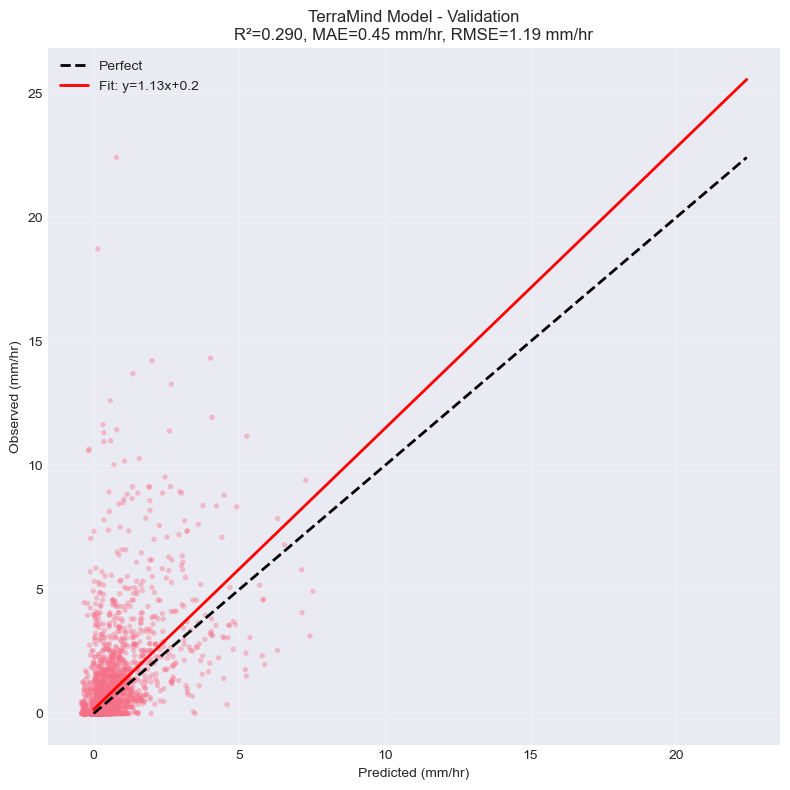


📊 Generating test scatter plot (daily)...

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575
✓ Saved: 03_terratorch_test_scatter.png

=== DIAGNOSTIC INFO ===
Val predictions: 5196 samples
  Min: -0.001, Max: 7.179, Mean: 0.450
Val truth: 5196 samples
  Min: 0.000, Max: 22.423, Mean: 0.520

R² Metrics:
  Standard R²:    0.295
  Correlation R²: 0.330 ← Compare to training notebook
  Pearson r:      0.575


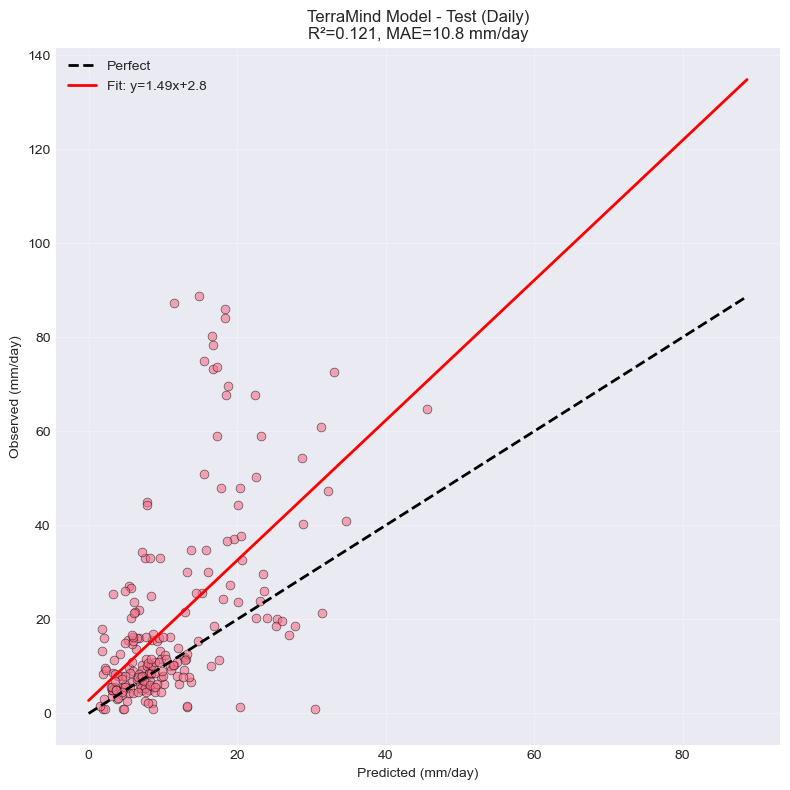


📊 Generating error by intensity plot...
     bin     n        mae       rmse       bias  mean_truth  mean_pred
0    0-1  1179   0.299200   0.448828   0.006853    0.330797   0.337651
1    1-5   657   1.408573   1.748024  -1.081677    2.237840   1.156163
2   5-10    86   4.776038   5.124810  -4.732516    6.861325   2.128809
3  10-20    19  10.602880  10.878309 -10.602880   12.079105   1.476226
4    20+     1  21.639805  21.639805 -21.639805   22.423000   0.783196
✓ Saved: 04_terratorch_validation_error_bins.png


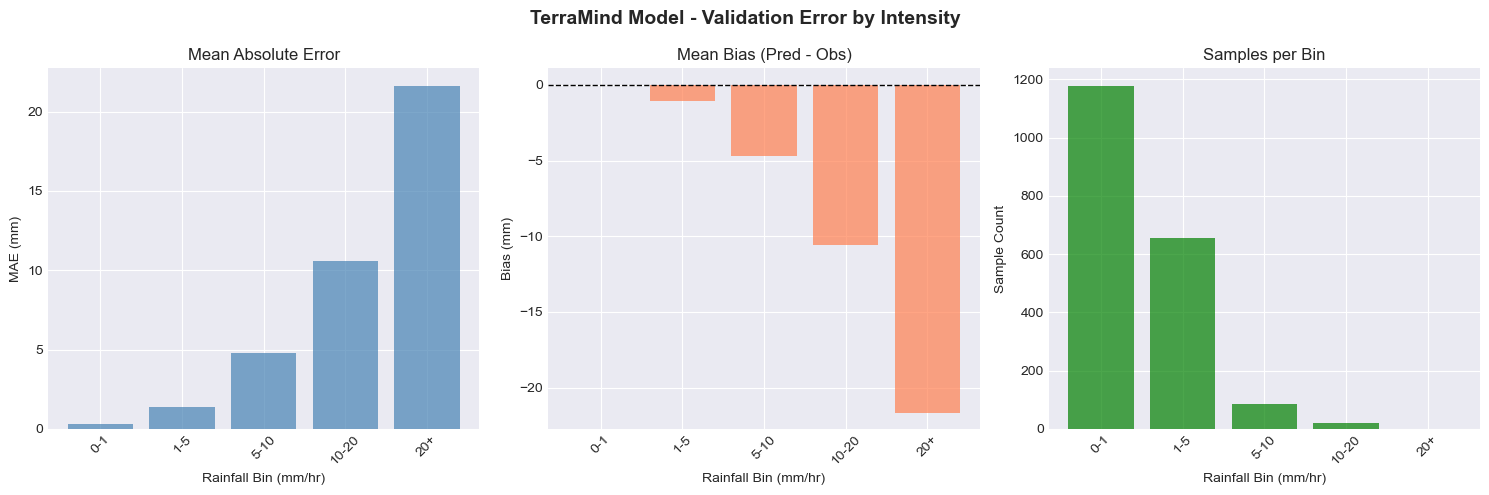


✓ All figures generated!


In [36]:
# ============================================================================
# 7. GENERATE MODEL PERFORMANCE FIGURES
# ============================================================================

print("\n" + "="*70)
print("MODEL PERFORMANCE VISUALIZATION")
print("="*70)

# ===== VALIDATION SCATTER PLOT =====
print("\n📊 Generating validation scatter plot...")
plot_scatter_with_stats(
    model_results['terratorch']['val_preds'],
    model_results['terratorch']['val_truth'],
    'TerraMind Model - Validation Set (Hourly)',
    f"{CONFIG['output_dir']}/02_terratorch_validation_scatter.png"
)
print("✓ Saved: 02_terratorch_validation_scatter.png")

# Also display inline
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_results['terratorch']['val_preds'], model_results['terratorch']['val_truth'], 
           alpha=0.4, s=15, edgecolors='none')
max_val = max(model_results['terratorch']['val_preds'].max(), model_results['terratorch']['val_truth'].max())
ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect', linewidth=2)

# Fit line
slope, intercept, r_val, _, _ = stats.linregress(model_results['terratorch']['val_preds'], 
                                                   model_results['terratorch']['val_truth'])
ax.plot([0, max_val], [intercept, slope*max_val + intercept], 'r-', 
        label=f'Fit: y={slope:.2f}x+{intercept:.1f}', linewidth=2)

metrics = compute_metrics(model_results['terratorch']['val_preds'], model_results['terratorch']['val_truth'])
ax.set_xlabel('Predicted (mm/hr)')
ax.set_ylabel('Observed (mm/hr)')
ax.set_title(f"TerraMind Model - Validation\nR²={metrics['r2']:.3f}, MAE={metrics['mae']:.2f} mm/hr, RMSE={metrics['rmse']:.2f} mm/hr")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== TEST SCATTER PLOT (DAILY) =====
print("\n📊 Generating test scatter plot (daily)...")
plot_scatter_with_stats(
    model_results['terratorch']['test_preds'],
    model_results['terratorch']['test_truth'],
    'TerraMind Model - Test Set (Daily)',
    f"{CONFIG['output_dir']}/03_terratorch_test_scatter.png"
)
print("✓ Saved: 03_terratorch_test_scatter.png")

# Also display inline
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_results['terratorch']['test_preds'], model_results['terratorch']['test_truth'], 
           alpha=0.6, s=40, edgecolors='k', linewidth=0.5)
max_val = max(model_results['terratorch']['test_preds'].max(), model_results['terratorch']['test_truth'].max())
ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect', linewidth=2)

slope, intercept, r_val, _, _ = stats.linregress(model_results['terratorch']['test_preds'], 
                                                   model_results['terratorch']['test_truth'])
ax.plot([0, max_val], [intercept, slope*max_val + intercept], 'r-', 
        label=f'Fit: y={slope:.2f}x+{intercept:.1f}', linewidth=2)

metrics_test = compute_metrics(model_results['terratorch']['test_preds'], model_results['terratorch']['test_truth'])
ax.set_xlabel('Predicted (mm/day)')
ax.set_ylabel('Observed (mm/day)')
ax.set_title(f"TerraMind Model - Test (Daily)\nR²={metrics_test['r2']:.3f}, MAE={metrics_test['mae']:.1f} mm/day")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== ERROR BY PRECIPITATION INTENSITY =====
print("\n📊 Generating error by intensity plot...")
hourly_bins = [0, 1, 5, 10, 20, np.inf]
hourly_labels = ['0-1', '1-5', '5-10', '10-20', '20+']

terratorch_val_binned = compute_binned_metrics(
    model_results['terratorch']['val_preds'],
    model_results['terratorch']['val_truth'],
    hourly_bins,
    hourly_labels
)
print(terratorch_val_binned)

plot_error_by_intensity(
    terratorch_val_binned,
    'TerraMind Model - Validation Error by Intensity',
    f"{CONFIG['output_dir']}/04_terratorch_validation_error_bins.png"
)
print("✓ Saved: 04_terratorch_validation_error_bins.png")

# Also display inline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(len(terratorch_val_binned))

axes[0].bar(x, terratorch_val_binned['mae'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Rainfall Bin (mm/hr)')
axes[0].set_ylabel('MAE (mm)')
axes[0].set_title('Mean Absolute Error')
axes[0].set_xticks(x)
axes[0].set_xticklabels(terratorch_val_binned['bin'], rotation=45)

axes[1].bar(x, terratorch_val_binned['bias'], alpha=0.7, color='coral')
axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('Rainfall Bin (mm/hr)')
axes[1].set_ylabel('Bias (mm)')
axes[1].set_title('Mean Bias (Pred - Obs)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(terratorch_val_binned['bin'], rotation=45)

axes[2].bar(x, terratorch_val_binned['n'], alpha=0.7, color='green')
axes[2].set_xlabel('Rainfall Bin (mm/hr)')
axes[2].set_ylabel('Sample Count')
axes[2].set_title('Samples per Bin')
axes[2].set_xticks(x)
axes[2].set_xticklabels(terratorch_val_binned['bin'], rotation=45)

fig.suptitle('TerraMind Model - Validation Error by Intensity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ All figures generated!")